# Разведочный анализ

In [7]:
import os
from pathlib import Path
from dotenv import load_dotenv
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [8]:
# Определяем путь к .env файлу относительно текущего ноутбука
env_path = Path.cwd().parent / 'infrastructure' / '.env'
# Загружаем переменные из указанного пути
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"Конфигурация загружена из: {env_path}")
else:
    print(f"Файл .env не найден по пути: {env_path}")

Конфигурация загружена из: /home/andrew/oncology_fhir_analytics/infrastructure/.env


In [11]:
# Подключаемся к ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    database=os.getenv('CLICKHOUSE_DB', 'default')
)

In [12]:
df = client.query_df("SELECT * FROM ready_for_ml")
print(f"Данные получены. Размер: {df.shape}")

Данные получены. Размер: (5703, 16)


In [13]:
df.head()

,patient_id,is_male,age_at_diag,feat_polyp_size,feat_pain_score,lab_hb,lab_mcv,lab_platelets,lab_bilirubin,lab_alk_phos,lab_creatinine,lab_glucose,raw_stage,target_advanced,death_event,survival_months
0,87fc29f3-c7c9-83e8-0002-d57959c8099f,0,71,3.8881,7.0,11.144,88.963,256.64,NaN,NaN,NaN,NaN,2,0,1,11
1,d0012d8f-6c2a-9072-0003-4f7ac4c1a0a0,0,56,3.8827,8.0,11.178,80.085,232.68,NaN,NaN,NaN,NaN,2,0,0,2
2,79eb6a31-1fbf-71fc-0011-34251ec955c0,0,76,24.6190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,1,43
3,474757a7-ade0-7c78-0021-396576a41915,0,61,2.7923,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0,69
4,e34174fe-09c6-d033-0028-9193743e79b3,0,75,12.9150,NaN,11.415,88.763,353.83,NaN,NaN,NaN,NaN,2,0,0,137


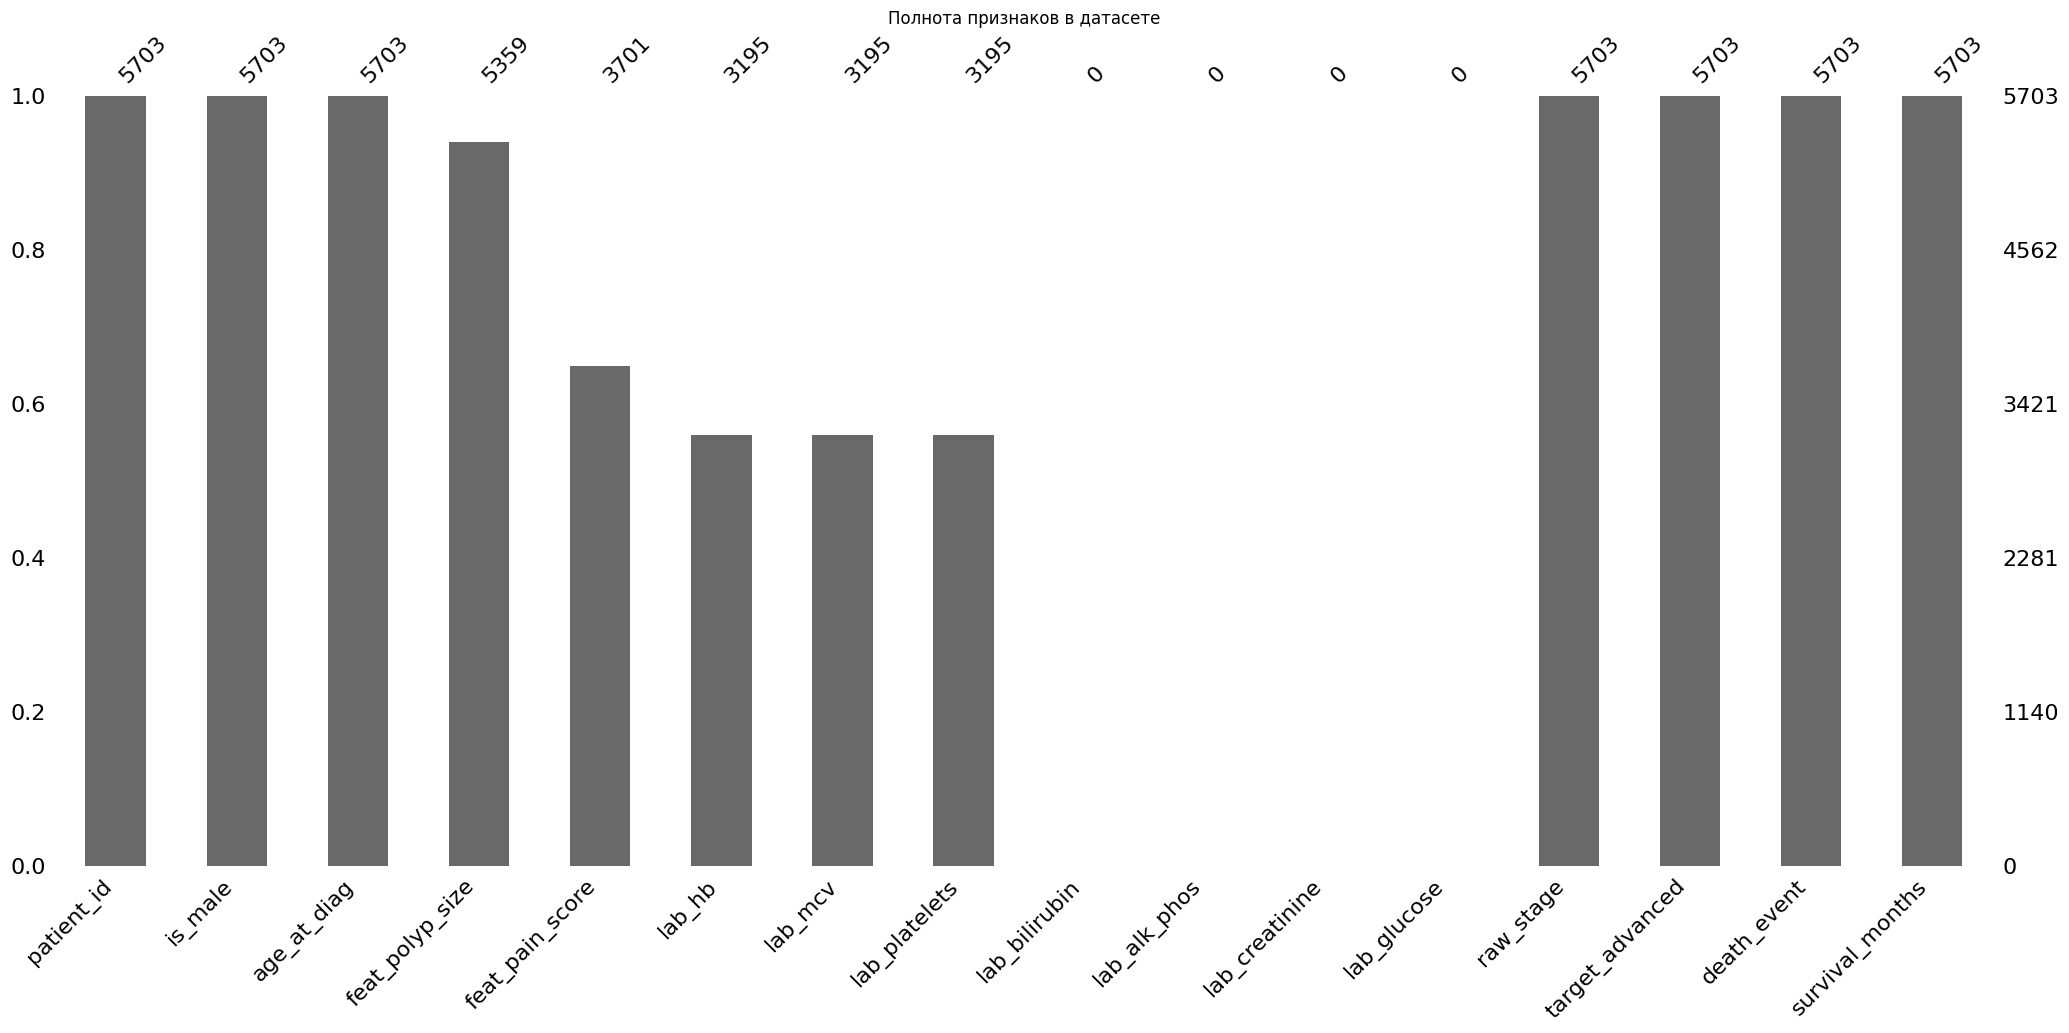

In [14]:
plt.figure(figsize=(12, 6))
msno.bar(df)
plt.title("Полнота признаков в датасете")
plt.show()

/tmp/ipykernel_91444/1596833291.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='raw_stage', data=df, ax=ax[1], palette='viridis')


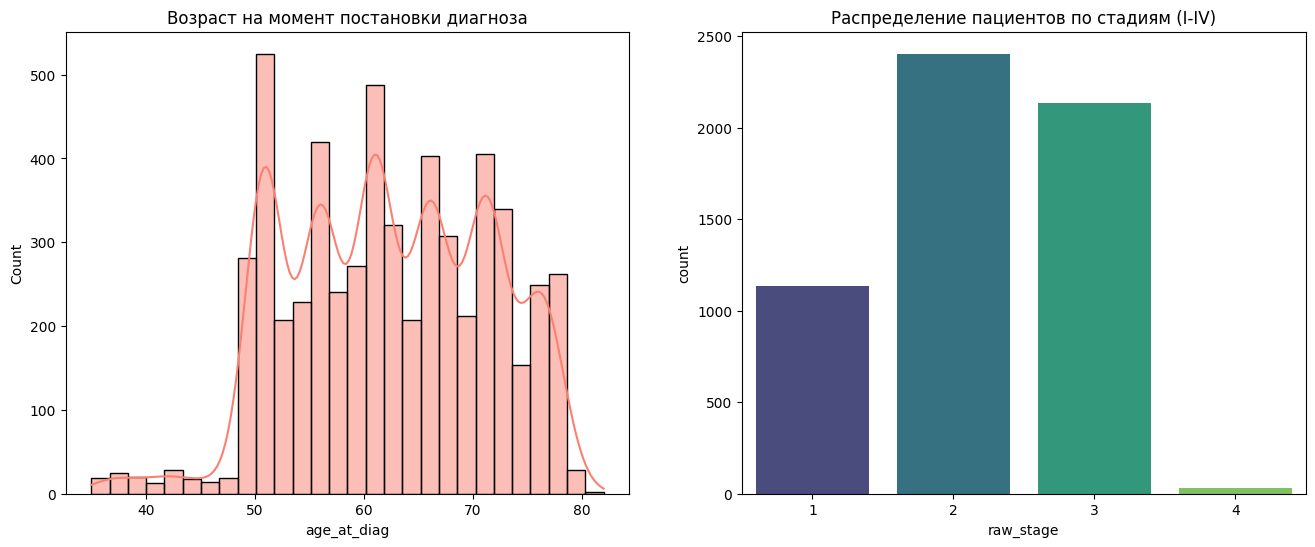

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Распределение возраста
sns.histplot(df['age_at_diag'], kde=True, ax=ax[0], color='salmon')
ax[0].set_title("Возраст на момент постановки диагноза")

# Распределение стадий
sns.countplot(x='raw_stage', data=df, ax=ax[1], palette='viridis')
ax[1].set_title("Распределение пациентов по стадиям (I-IV)")

plt.show()

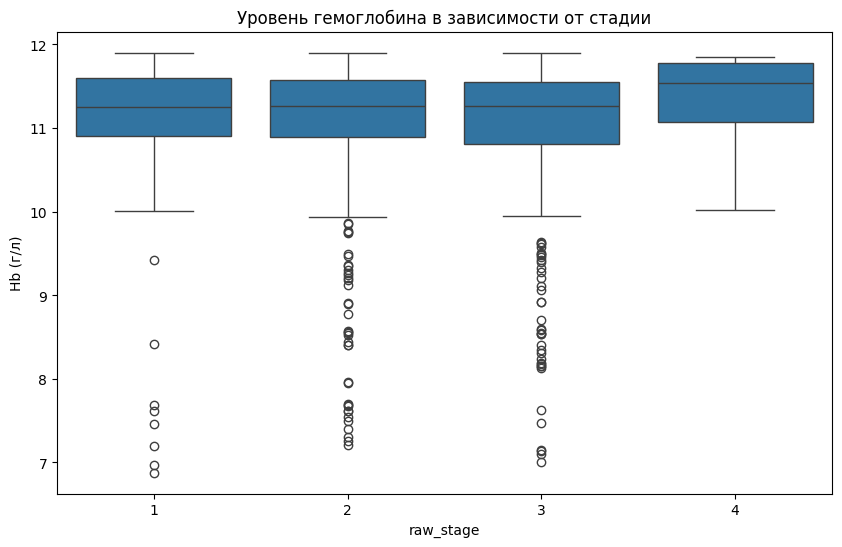

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='raw_stage', y='lab_hb', data=df)
plt.title("Уровень гемоглобина в зависимости от стадии")
plt.ylabel("Hb (г/л)")
plt.show()

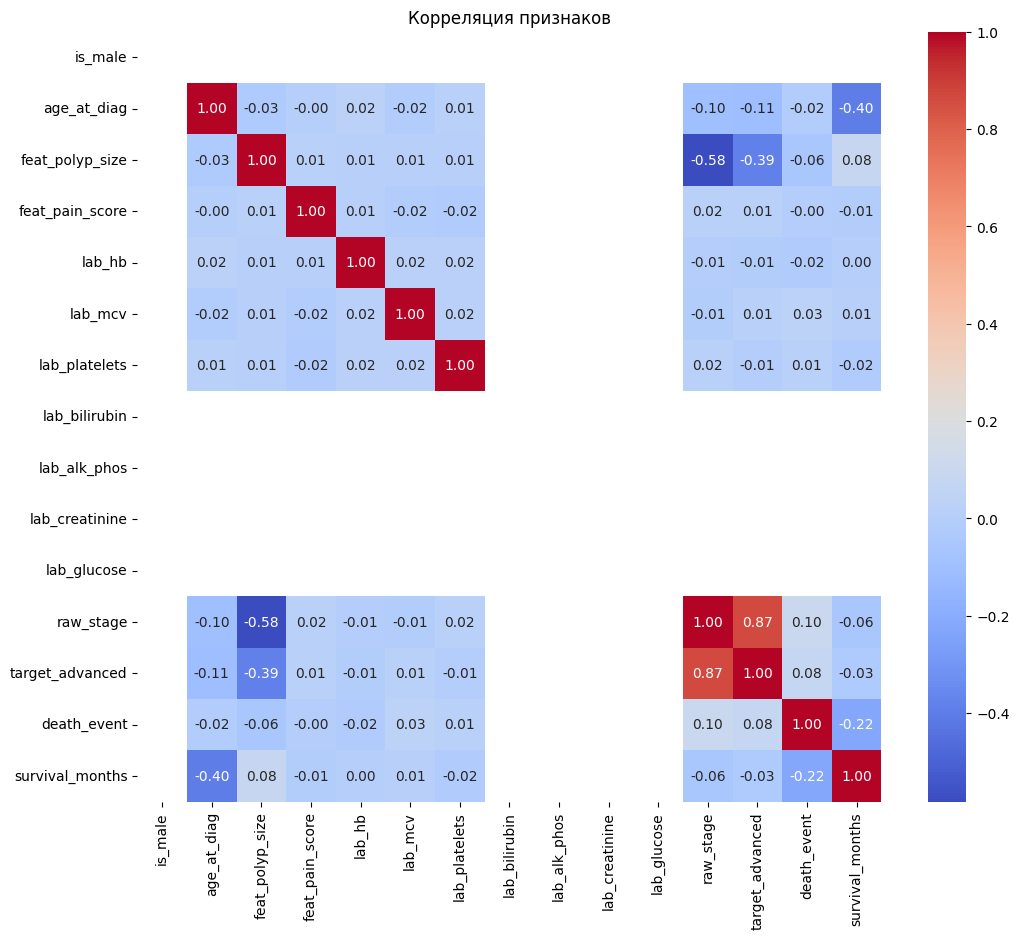

In [17]:
plt.figure(figsize=(12, 10))
# Исключаем UUID для корреляции
corr = df.drop(columns=['patient_id']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция признаков")
plt.show()

In [18]:
df.describe()

,is_male,age_at_diag,feat_polyp_size,feat_pain_score,lab_hb,lab_mcv,lab_platelets,lab_bilirubin,lab_alk_phos,lab_creatinine,lab_glucose,raw_stage,target_advanced,death_event,survival_months
count,5703.0,5703.000000,5359.000000,3701.000000,3195.000000,3195.000000,3195.000000,0.0,0.0,0.0,0.0,5703.000000,5703.00000,5703.000000,5703.000000
mean,0.0,62.350868,8.752261,6.484734,11.122885,87.519636,299.644607,NaN,NaN,NaN,NaN,2.186393,0.37980,0.505699,135.212870
std,0.0,9.065517,6.700036,0.969032,0.665719,4.290843,86.231139,NaN,NaN,NaN,NaN,0.748067,0.48538,0.500011,113.921377
min,0.0,35.000000,2.007000,5.000000,6.877400,80.001000,150.150000,NaN,NaN,NaN,NaN,1.000000,0.00000,0.000000,1.000000
25%,0.0,56.000000,3.818150,6.000000,10.867500,83.874500,225.890000,NaN,NaN,NaN,NaN,2.000000,0.00000,0.000000,42.000000
50%,0.0,62.000000,5.765900,6.000000,11.264000,87.401000,301.710000,NaN,NaN,NaN,NaN,2.000000,0.00000,1.000000,97.000000
75%,0.0,71.000000,13.568500,7.000000,11.577000,91.152000,374.580000,NaN,NaN,NaN,NaN,3.000000,1.00000,1.000000,206.000000
max,0.0,82.000000,24.994000,8.000000,11.899000,94.999000,449.960000,NaN,NaN,NaN,NaN,4.000000,1.00000,1.000000,593.000000
